In [1]:
import numpy as np
import healpy as hp
from healpy.newvisufunc import projview
from astropy.table import Table

import matplotlib
from matplotlib import pyplot as plt

from Corrfunc import mocks
from Corrfunc.utils import convert_rp_pi_counts_to_wp
from scipy import constants
from scipy import stats
import scipy.interpolate as interp
import matplotlib.gridspec as gridspec
from astropy.cosmology import FlatLambdaCDM
import astropy.cosmology.units as cu
import astropy.units as u
from astropy.io import fits
import quaia
from astropy.coordinates import SkyCoord

In [2]:
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['xtick.labelsize'] = 18
plt.rcParams['axes.labelsize'] = 22
plt.rcParams['legend.fontsize'] = 18

plt.rcParams['axes.titlesize'] = 20

In [3]:
cmap_map = 'plasma'

# Load data from local machine

In [4]:
# mocks
fn_gcatlo = f'../Quaia_mock_catalogs-20250211T213139Z-001/Quaia_mock_catalogs/G20/mock_catalog_quaia_G20_mock1.fits'
fn_gcathi = f'../Quaia_mock_catalogs-20250211T213139Z-001/Quaia_mock_catalogs/G20.5/mock_catalog_quaia_G20.5_mock1.fits'

# randoms
fn_randlo = f'../data/randoms/random_G20.0_10x.fits'
fn_randhi = f'../data/randoms/random_G20.5_10x.fits'

# data
fn_datalo = f'../data/quaia_G20.0.fits'
fn_datahi = f'../data/quaia_G20.5.fits'

In [5]:
fn_sello = f'../data/maps/selection_function_NSIDE64_G20.0.fits'
fn_selhi = f'../data/maps/selection_function_NSIDE64_G20.5.fits'

## Parameters

In [6]:
NSIDE = 64
NPIX = hp.nside2npix(NSIDE)

In [7]:
name_catalog = '$Gaia$-$unWISE$ Quasar Mock Catalog'
abbrv_catalog = 'Quaia'

In [8]:
G_hi = 20.5
G_lo = 20.0

In [9]:
# for plotting purposes
fac_stdev = 0.5 #1.45 #1.5

## Quasar mock catalog

In [10]:
tab_gcatlo = Table.read(fn_gcatlo)
N_gcatlo = len(tab_gcatlo)
print(f"Number of data sources: {N_gcatlo}")

Number of data sources: 755512


In [11]:
print(tab_gcatlo.meta)

OrderedDict()


In [12]:
print(f"Column names: {tab_gcatlo.columns}")

Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>


In [13]:
tab_gcathi = Table.read(fn_gcathi)
N_gcathi = len(tab_gcathi)
print(f"Number of data sources: {N_gcathi}")

Number of data sources: 1295221


### Make map of quasar number counts

In [14]:
# mask the plane
mask = 20
c_gcatlo = SkyCoord(ra=tab_gcatlo['ra']*u.degree, dec=tab_gcatlo['dec']*u.degree)
mask_gcatlo = np.abs(c_gcatlo.galactic.b.value)>=mask # use galactic coordinates from data 
N_gcatlo_mask = len(tab_gcatlo['ra'][mask_gcatlo])

In [15]:
pixel_indices_gcatlo_mask = hp.ang2pix(NSIDE, tab_gcatlo['ra'][mask_gcatlo], tab_gcatlo['dec'][mask_gcatlo], lonlat=True)
map_gcatlo = np.bincount(pixel_indices_gcatlo_mask, minlength=NPIX)

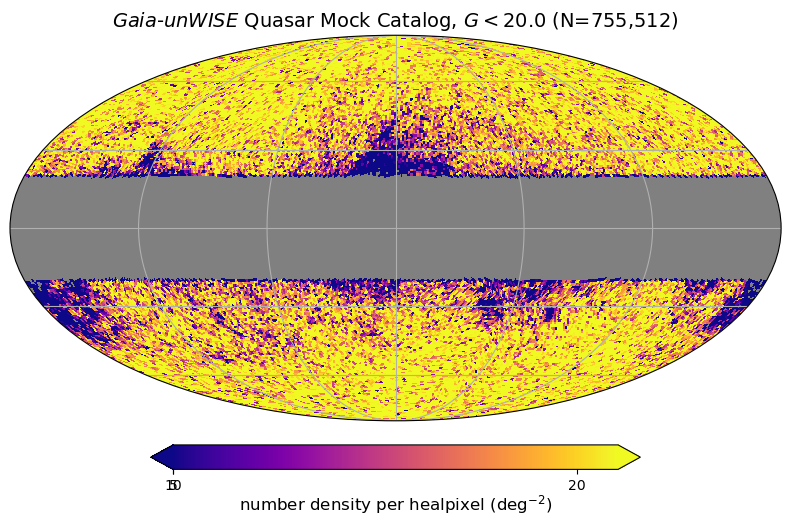

In [16]:
title_gcatlo = rf"{name_catalog}, $G<{G_lo}$ (N={len(tab_gcatlo):,})"
projview(map_gcatlo, title=title_gcatlo,
            unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
            min=np.median(map_gcatlo)-fac_stdev*np.std(map_gcatlo), max=np.median(map_gcatlo)+fac_stdev*np.std(map_gcatlo), 
            norm='log', graticule=True,
            cbar_ticks=[5, 10, 20]) 

In [17]:
c_gcathi = SkyCoord(ra=tab_gcathi['ra']*u.degree, dec=tab_gcathi['dec']*u.degree)
mask_gcathi = np.abs(c_gcathi.galactic.b.value)>=mask # use galactic coordinates from data 
N_gcathi_mask = len(tab_gcathi['ra'][mask_gcathi])

In [18]:
pixel_indices_gcathi_mask = hp.ang2pix(NSIDE, tab_gcathi['ra'][mask_gcathi], tab_gcathi['dec'][mask_gcathi], lonlat=True)
map_gcathi = np.bincount(pixel_indices_gcathi_mask, minlength=NPIX)

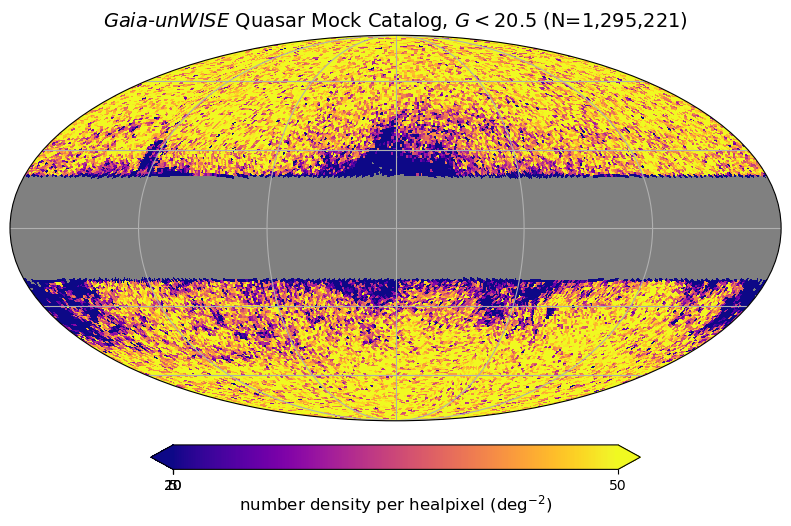

In [19]:
title_gcathi = rf"{name_catalog}, $G<{G_hi}$ (N={len(tab_gcathi):,})"
projview(map_gcathi, title=title_gcathi,
            unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
            min=np.median(map_gcathi)-fac_stdev*np.std(map_gcathi), max=np.median(map_gcathi)+fac_stdev*np.std(map_gcathi), 
            norm='log', graticule=True,
            cbar_ticks=[5, 10, 20, 50])

## Random catalog

In [20]:
tab_randlo = Table.read(fn_randlo)
N_randlo = len(tab_randlo)
print(f"Number of random sources: {N_randlo}")

Number of random sources: 7563151


In [21]:
print(f"Column names: {tab_randlo.columns}")

Column names: <TableColumns names=('ra','dec','ebv')>


In [22]:
tab_randhi = Table.read(fn_randhi)
N_randhi = len(tab_randhi)
print(f"Number of random sources: {N_randhi}")

Number of random sources: 12955802


### Make maps of random number counts

In [23]:
c_randlo = SkyCoord(ra=tab_randlo['ra'], dec=tab_randlo['dec'])
mask_randlo = np.abs(c_randlo.galactic.b.value)>=mask # use galactic coordinates from data 
N_randlo_mask = len(tab_randlo['ra'][mask_randlo])

In [24]:
pixel_indices_randlo_mask = hp.ang2pix(NSIDE, tab_randlo['ra'][mask_randlo], tab_randlo['dec'][mask_randlo], lonlat=True)
map_randlo = np.bincount(pixel_indices_randlo_mask, minlength=NPIX)

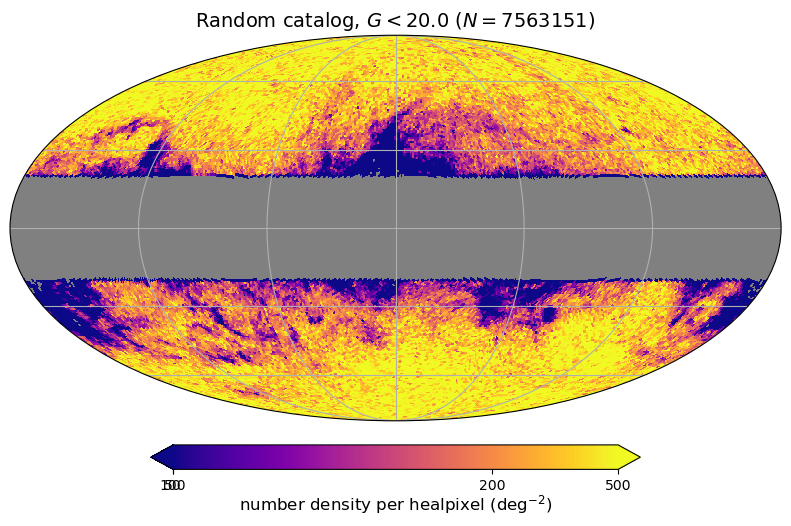

In [25]:
projview(map_randlo, title=rf"Random catalog, $G<{G_lo}$ ($N={N_randlo}$)",
            unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
            min=np.median(map_randlo)-fac_stdev*np.std(map_randlo), 
            max=np.median(map_randlo)+fac_stdev*np.std(map_randlo), 
            norm='log', graticule=True,
            cbar_ticks=[50, 100, 200, 500]) 

In [26]:
c_randhi = SkyCoord(ra=tab_randhi['ra'], dec=tab_randhi['dec'])
mask_randhi = np.abs(c_randhi.galactic.b.value)>=mask # use galactic coordinates from data 
N_randhi_mask = len(tab_randhi['ra'][mask_randhi])

In [27]:
pixel_indices_randhi_mask = hp.ang2pix(NSIDE, tab_randhi['ra'][mask_randhi], tab_randhi['dec'][mask_randhi], lonlat=True)
map_randhi = np.bincount(pixel_indices_randhi_mask, minlength=NPIX)

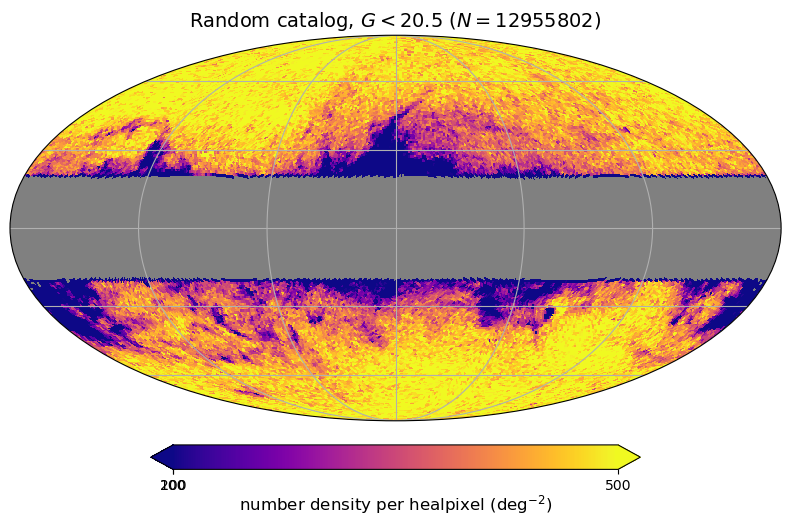

In [28]:
projview(map_randhi, title=rf"Random catalog, $G<{G_hi}$ ($N={N_randhi}$)",
            unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
            min=np.median(map_randhi)-fac_stdev*np.std(map_randhi), max=np.median(map_randhi)+fac_stdev*np.std(map_randhi), 
            norm='log', graticule=True,
            cbar_ticks=[100, 200, 500]) 

## Data

In [29]:
tab_datalo = Table.read(fn_datalo)
N_datalo = len(tab_datalo)
print(f"Number of random sources: {N_datalo}")

Number of random sources: 755850


In [30]:
print(f"Column names: {tab_datalo.columns}")

Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


In [31]:
tab_datahi = Table.read(fn_datahi)
N_datahi = len(tab_datahi)
print(f"Number of random sources: {N_datahi}")

Number of random sources: 1295502


### Make maps of data number counts

In [32]:
c_datalo = SkyCoord(ra=tab_datalo['ra'], dec=tab_datalo['dec'])
mask_datalo = np.abs(c_datalo.galactic.b.value)>=mask # use galactic coordinates from data 
N_datalo_mask = len(tab_datalo['ra'][mask_datalo])

In [33]:
pixel_indices_datalo_mask = hp.ang2pix(NSIDE, tab_datalo['ra'][mask_datalo], tab_datalo['dec'][mask_datalo], lonlat=True)
map_datalo = np.bincount(pixel_indices_datalo_mask, minlength=NPIX)

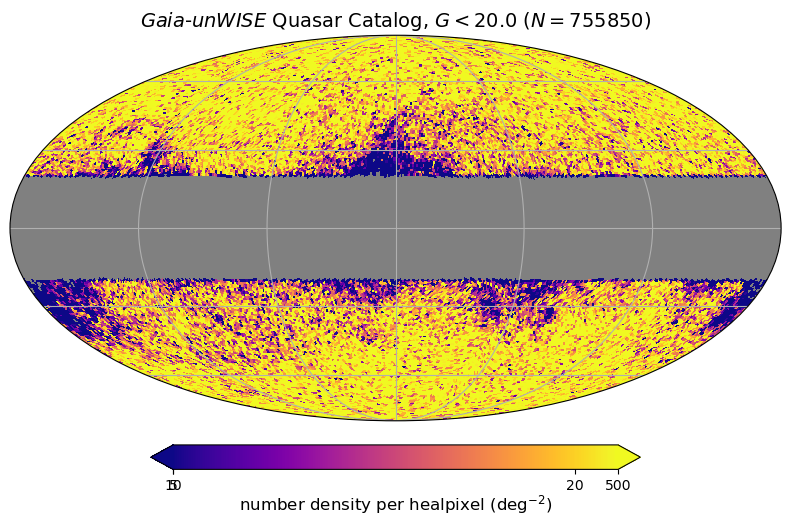

In [34]:
projview(map_datalo, title=rf"$Gaia$-$unWISE$ Quasar Catalog, $G<{G_lo}$ ($N={N_datalo}$)",
            unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
            min=np.median(map_datalo)-fac_stdev*np.std(map_datalo), 
            max=np.median(map_datalo)+fac_stdev*np.std(map_datalo), 
            norm='log', graticule=True,
            cbar_ticks=[5, 10, 20, 500]) 

In [35]:
c_datahi = SkyCoord(ra=tab_datahi['ra'], dec=tab_datahi['dec'])
mask_datahi = np.abs(c_datahi.galactic.b.value)>=mask # use galactic coordinates from data 
N_datahi_mask = len(tab_datahi['ra'][mask_datahi])

In [36]:
pixel_indices_datahi_mask = hp.ang2pix(NSIDE, tab_datahi['ra'][mask_datahi], tab_datahi['dec'][mask_datahi], lonlat=True)
map_datahi = np.bincount(pixel_indices_datahi_mask, minlength=NPIX)

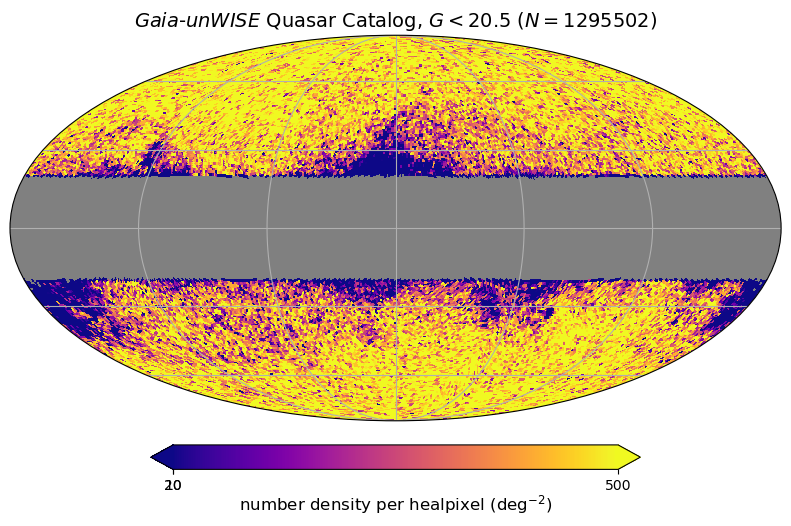

In [37]:
projview(map_datahi, title=rf"$Gaia$-$unWISE$ Quasar Catalog, $G<{G_hi}$ ($N={N_datahi}$)",
            unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
            min=np.median(map_datahi)-fac_stdev*np.std(map_datahi), max=np.median(map_datahi)+fac_stdev*np.std(map_datahi), 
            norm='log', graticule=True,
            cbar_ticks=[10, 20, 500]) 

## Remove the selection function
### Start with mock catalogs

In [38]:
selfunc_lo = hp.fitsfunc.read_map(fn_sello)

In [39]:
map_selfunc_lo = map_gcatlo/selfunc_lo

/tmp/ipykernel_28443/515644528.py:1: RuntimeWarning: invalid value encountered in true_divide
  map_selfunc_lo = map_gcatlo/selfunc_lo


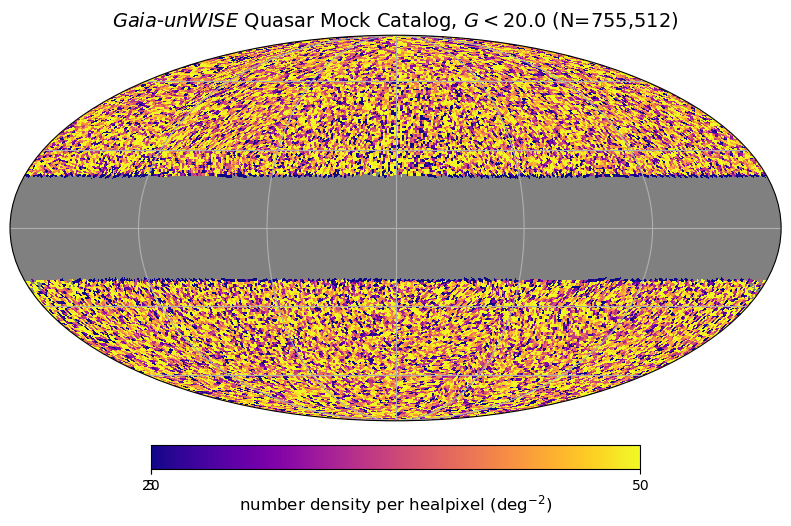

In [40]:
title_gcatlo = rf"{name_catalog}, $G<{G_lo}$ (N={len(tab_gcatlo):,})"
projview(map_selfunc_lo, title=title_gcatlo,
            unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
            min=np.nanmedian(map_selfunc_lo)-fac_stdev*np.nanstd(map_selfunc_lo), max=np.nanmedian(map_selfunc_lo)+fac_stdev*np.nanstd(map_selfunc_lo), 
            norm='log', graticule=True,
            cbar_ticks=[5, 20, 50]) 

In [41]:
selfunc_hi = hp.fitsfunc.read_map(fn_selhi)

In [42]:
map_selfunc_hi = map_gcathi/selfunc_hi

/tmp/ipykernel_28443/189966545.py:1: RuntimeWarning: invalid value encountered in true_divide
  map_selfunc_hi = map_gcathi/selfunc_hi


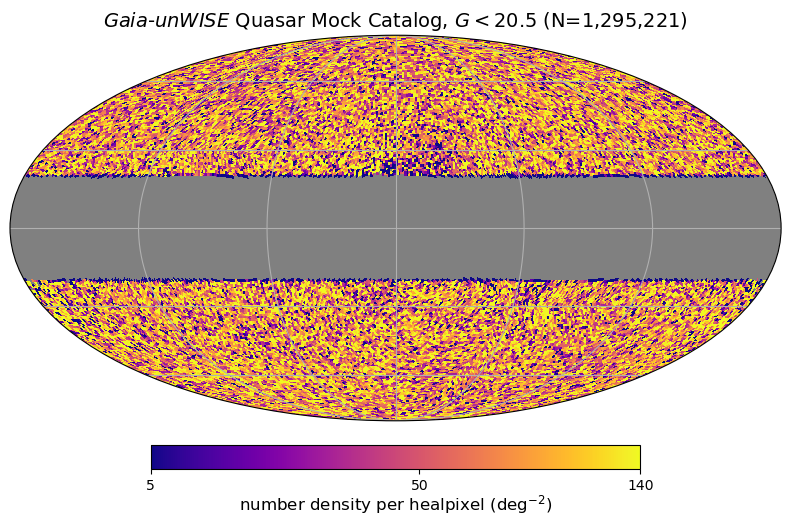

In [43]:
title_gcathi = rf"{name_catalog}, $G<{G_hi}$ (N={len(tab_gcathi):,})"
projview(map_selfunc_hi, title=title_gcathi,
            unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
            min=np.nanmedian(map_selfunc_hi)-fac_stdev*np.nanstd(map_selfunc_hi), max=np.nanmedian(map_selfunc_hi)+fac_stdev*np.nanstd(map_selfunc_hi), 
            norm='log', graticule=True,
            cbar_ticks=[5, 50, 140]) 

### Now random catalog

In [44]:
map_randselfunc_lo = map_randlo/selfunc_lo

/tmp/ipykernel_28443/1639919514.py:1: RuntimeWarning: invalid value encountered in true_divide
  map_randselfunc_lo = map_randlo/selfunc_lo


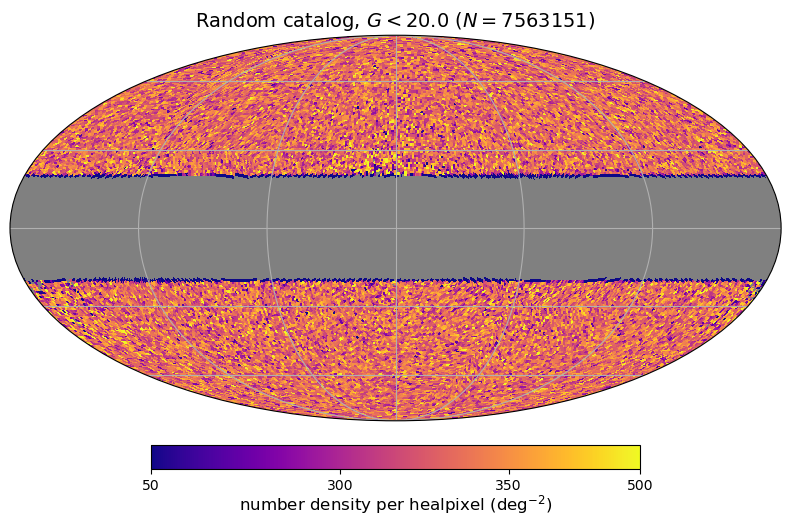

In [45]:
projview(map_randselfunc_lo, title=rf"Random catalog, $G<{G_lo}$ ($N={N_randlo}$)",
            unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
            min=np.nanmedian(map_randselfunc_lo)-fac_stdev*np.nanstd(map_randselfunc_lo), 
            max=np.nanmedian(map_randselfunc_lo)+fac_stdev*np.nanstd(map_randselfunc_lo), 
            norm='log', graticule=True,
            cbar_ticks=[50, 300, 350, 500]) 

In [46]:
map_randselfunc_hi = map_randhi/selfunc_hi

/tmp/ipykernel_28443/231715387.py:1: RuntimeWarning: invalid value encountered in true_divide
  map_randselfunc_hi = map_randhi/selfunc_hi


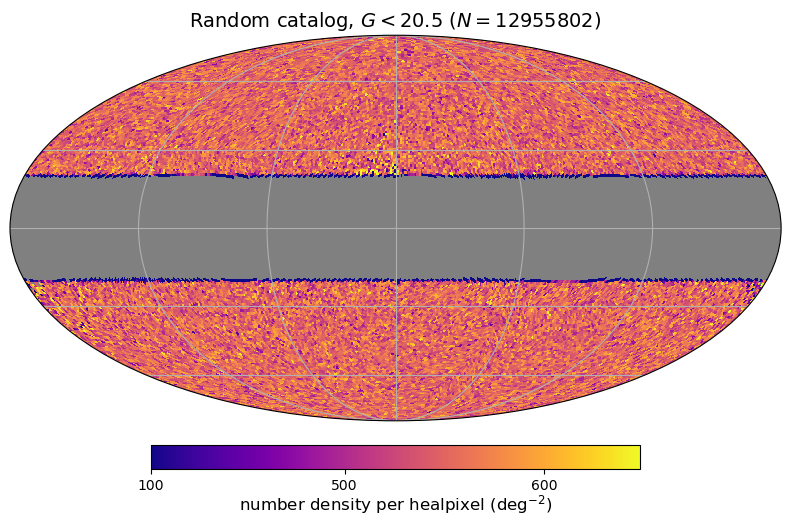

In [47]:
projview(map_randselfunc_hi, title=rf"Random catalog, $G<{G_hi}$ ($N={N_randhi}$)",
         unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
         min=np.nanmedian(map_randselfunc_hi)-fac_stdev*np.nanstd(map_randselfunc_hi), 
         max=np.nanmedian(map_randselfunc_hi)+fac_stdev*np.nanstd(map_randselfunc_hi), norm='log', graticule=True, 
         cbar_ticks=[100, 500, 600]) 

## Now data

In [48]:
map_dataselfunc_lo = map_datalo/selfunc_lo

/tmp/ipykernel_28443/184702458.py:1: RuntimeWarning: invalid value encountered in true_divide
  map_dataselfunc_lo = map_datalo/selfunc_lo


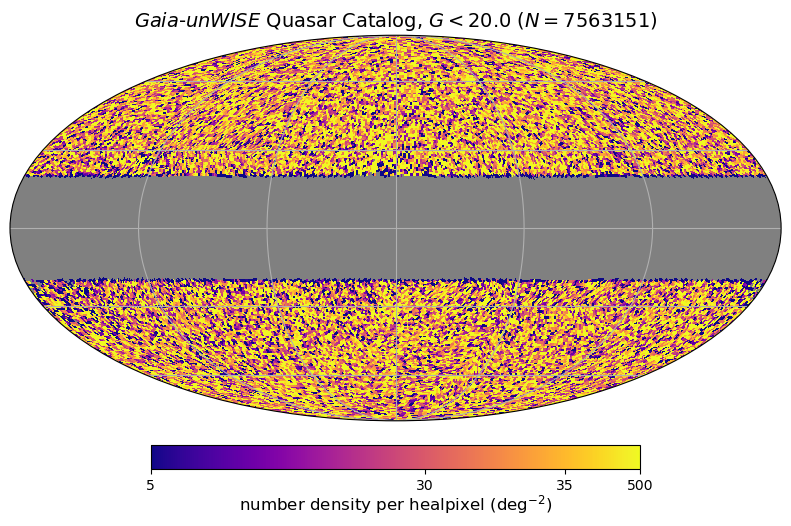

In [49]:
projview(map_dataselfunc_lo, title=rf"$Gaia$-$unWISE$ Quasar Catalog, $G<{G_lo}$ ($N={N_randlo}$)",
            unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
            min=np.nanmedian(map_dataselfunc_lo)-fac_stdev*np.nanstd(map_dataselfunc_lo), 
            max=np.nanmedian(map_dataselfunc_lo)+fac_stdev*np.nanstd(map_dataselfunc_lo), 
            norm='log', graticule=True,
            cbar_ticks=[5, 30, 35, 500]) 

In [50]:
map_dataselfunc_hi = map_datahi/selfunc_hi

/tmp/ipykernel_28443/2719846951.py:1: RuntimeWarning: invalid value encountered in true_divide
  map_dataselfunc_hi = map_datahi/selfunc_hi


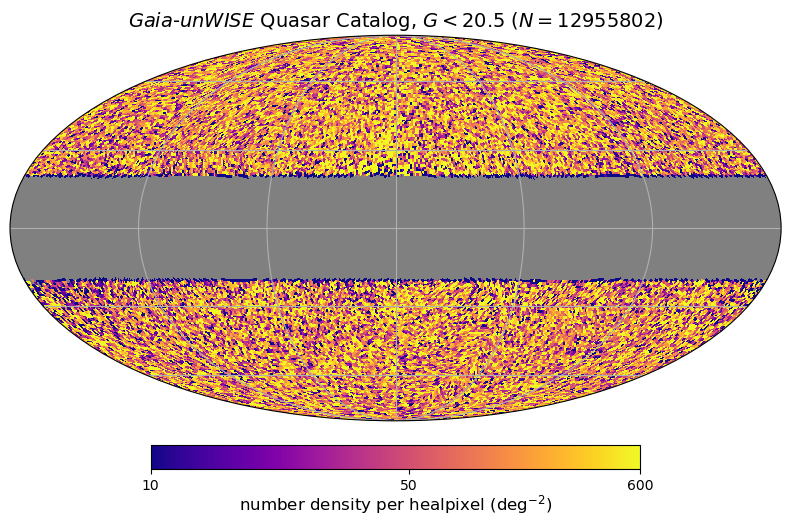

In [51]:
projview(map_dataselfunc_hi, title=rf"$Gaia$-$unWISE$ Quasar Catalog, $G<{G_hi}$ ($N={N_randhi}$)",
         unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
         min=np.nanmedian(map_dataselfunc_hi)-fac_stdev*np.nanstd(map_dataselfunc_hi), 
         max=np.nanmedian(map_dataselfunc_hi)+fac_stdev*np.nanstd(map_dataselfunc_hi), norm='log', graticule=True, 
         cbar_ticks=[10, 50, 600]) 

# Plot the $n(z)$ distribution

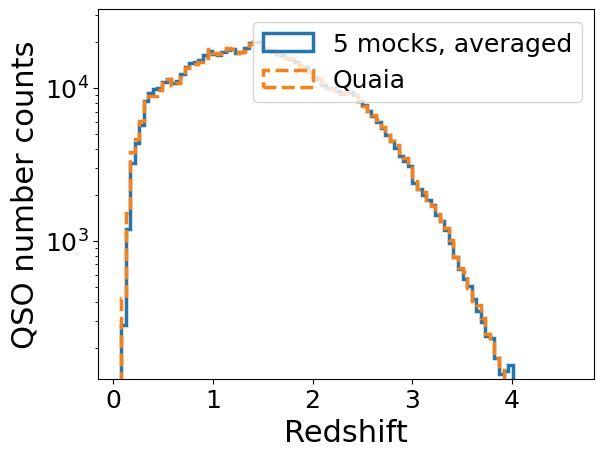

In [52]:
mean = []
bins = np.linspace(0.08, 4.6, 100)
for i in range(1,6):

    fn_gcatlo_i = '../Quaia_mock_catalogs-20250211T213139Z-001/Quaia_mock_catalogs/G20/mock_catalog_quaia_G20_mock{:s}.fits'.format(str(i))
    tab_gcatlo_i = Table.read(fn_gcatlo_i)
    hist, bin_edges = np.histogram(tab_gcatlo_i['redshift_quaia'], bins = bins)
    mean.append(hist)
    
plt.hist(bins[:-1], bins, weights = np.mean(mean, axis = 0), histtype = 'step', label = '5 mocks, averaged', linewidth = 2.5)
plt.hist(tab_datalo['redshift_quaia'], histtype = 'step', label = 'Quaia', bins = bins, linestyle = '--', linewidth = 2.5)
plt.xlabel('Redshift')
plt.ylabel('QSO number counts')
plt.yscale('log')
plt.ylim(125,)
plt.legend()
plt.show()

# Compute the projected angular auto-power spectrum
## First measure the pair counts

In [53]:
# Create the bins array
rmin = 0.15 # 0.5 # 0.1 # start higher
rmax = 85 # 60.0 # 20.0 
nbins = 20 
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202

In [54]:
pimax = 80 # 40 # 5000.0 # 40.0

In [55]:
nthreads = 18

In [56]:
ind = np.argsort(tab_gcatlo['redshift_quaia'])

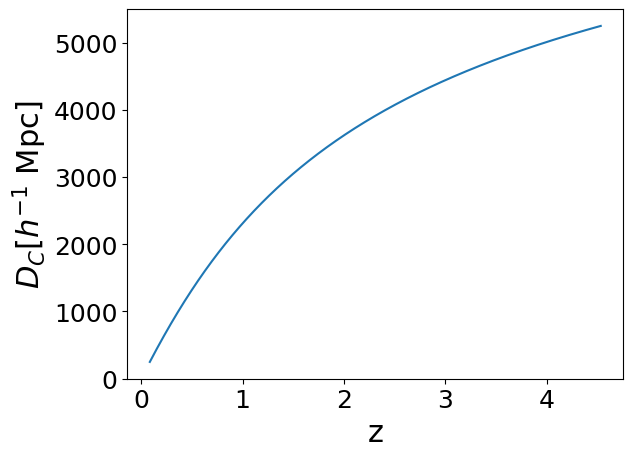

In [57]:
plt.plot(tab_gcatlo['redshift_quaia'][ind], quaia.comoving_dist(tab_gcatlo['redshift_quaia'])[ind], label = '$D_C$')
plt.xlabel('z')
plt.ylabel('$D_C[h^{-1}$ Mpc]')
plt.show()

In [58]:
# comoving distance                    # where hubble distance = c/H0 and H0 = 100 km/s/Mpc h # convert from Mpc to Mpc/h
DD_counts, api_time = mocks.DDrppi_mocks(autocorr = 1, cosmology = 2, nthreads = nthreads, pimax = pimax, binfile = rbins, 
                                         RA1 = tab_gcatlo['ra'][mask_gcatlo], DEC1 = tab_gcatlo['dec'][mask_gcatlo],  
                                         CZ1 = quaia.comoving_dist(tab_gcatlo['redshift_quaia'][mask_gcatlo]), 
                                         weights1 = 1/selfunc_lo[pixel_indices_gcatlo_mask], is_comoving_dist = True, weight_type='pair_product', 
                                         output_rpavg = True, c_api_timer = True)

api_time

/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


0.788029

## Generate a $z$ distribution for the random catalog
### Try interpolating the cdf so it's more smooth

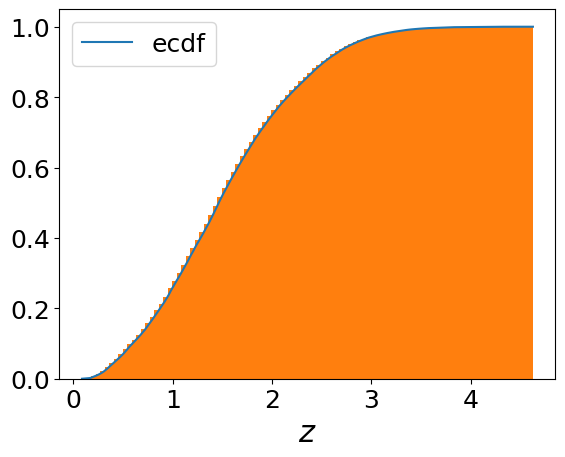

In [59]:
quaia.z_dist(tab_datalo, tab_randlo, mask_datalo, mask_randlo, N_datalo_mask, N_randlo_mask, plot = True, mask = mask)

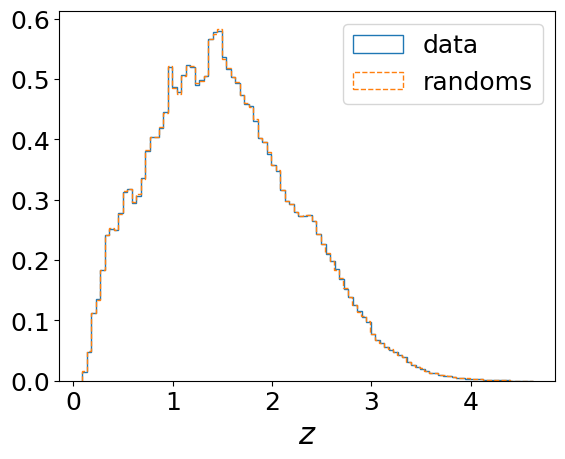

In [60]:
plt.hist(tab_datalo['redshift_quaia'][mask_datalo], histtype = 'step', density = True, label = 'data', bins = 100)
plt.hist(tab_randlo['redshift_quaia_'+str(mask)][mask_randlo], histtype = 'step', density = True, label = 'randoms', bins = 100, linestyle = '--')
plt.xlabel('$z$')
plt.legend()
plt.show()

### Now measure clustering in random catalog

In [61]:
d = 1

In [62]:
DR_counts, api_time = mocks.DDrppi_mocks(autocorr = 0, cosmology = 2, nthreads = nthreads, pimax = pimax, binfile = rbins, 
                                         RA1 = tab_gcatlo['ra'][mask_gcatlo], DEC1 = tab_gcatlo['dec'][mask_gcatlo], 
                                         CZ1 = quaia.comoving_dist(tab_gcatlo['redshift_quaia'][mask_gcatlo]), 
                                         weights1 = 1/selfunc_lo[pixel_indices_gcatlo_mask],
                                         RA2 = tab_randlo['ra'][mask_randlo][::d], DEC2 = tab_randlo['dec'][mask_randlo][::d],
                                         CZ2 = quaia.comoving_dist(tab_randlo['redshift_quaia_'+str(mask)][mask_randlo][::d]), 
                                         weights2 = 1/selfunc_lo[pixel_indices_randlo_mask][::d], weight_type='pair_product', 
                                         is_comoving_dist = True, output_rpavg = True, c_api_timer = True)

api_time

/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


10.321675

In [63]:
RR_counts, api_time = mocks.DDrppi_mocks(autocorr = 1, cosmology = 2, nthreads = nthreads, pimax = pimax, binfile = rbins, 
                                         RA1 = tab_randlo['ra'][mask_randlo][::d], DEC1 = tab_randlo['dec'][mask_randlo][::d], 
                                         CZ1 = quaia.comoving_dist(tab_randlo['redshift_quaia_'+str(mask)][mask_randlo][::d]), 
                                         weights1 = 1/selfunc_lo[pixel_indices_randlo_mask][::d], weight_type='pair_product',
                                         is_comoving_dist = True, output_rpavg = True, c_api_timer = True)

api_time

15.102549

### Plot for sanity check

In [64]:
DD_counts['npairs'] = DD_counts['npairs']*DD_counts['weightavg']
DR_counts['npairs'] = DR_counts['npairs']*DR_counts['weightavg']
RR_counts['npairs'] = RR_counts['npairs']*RR_counts['weightavg']

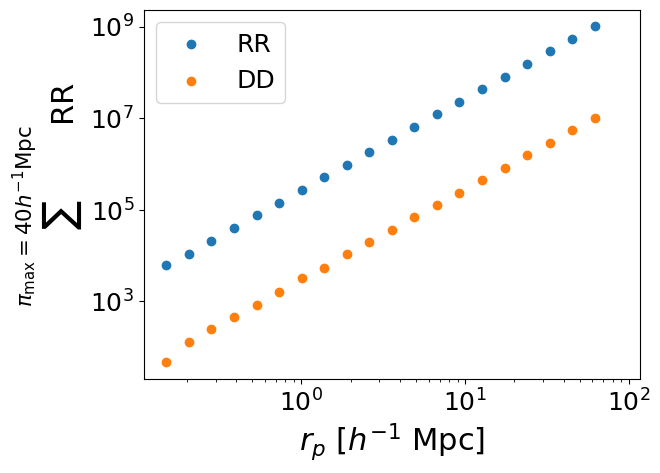

In [65]:
plt.scatter(rbins, [np.sum(RR_counts['npairs'][RR_counts['rmin']==i]) for i in rbins], label = 'RR')
plt.scatter(rbins, [np.sum(DD_counts['npairs'][DD_counts['rmin']==i]) for i in rbins], label = 'DD')
plt.xlabel(r'$r_{p}$ $[h^{-1}$ Mpc]') # projected
plt.ylabel('$\sum^{\pi_\mathrm{max}=40h^{-1}\mathrm{Mpc}}$RR')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

In [66]:
def plot_counts(counts, key, cut, ax, x, label):
    
    pimax = counts[key]==cut
    ax.scatter(counts[x][pimax], counts['npairs'][pimax], label = label)

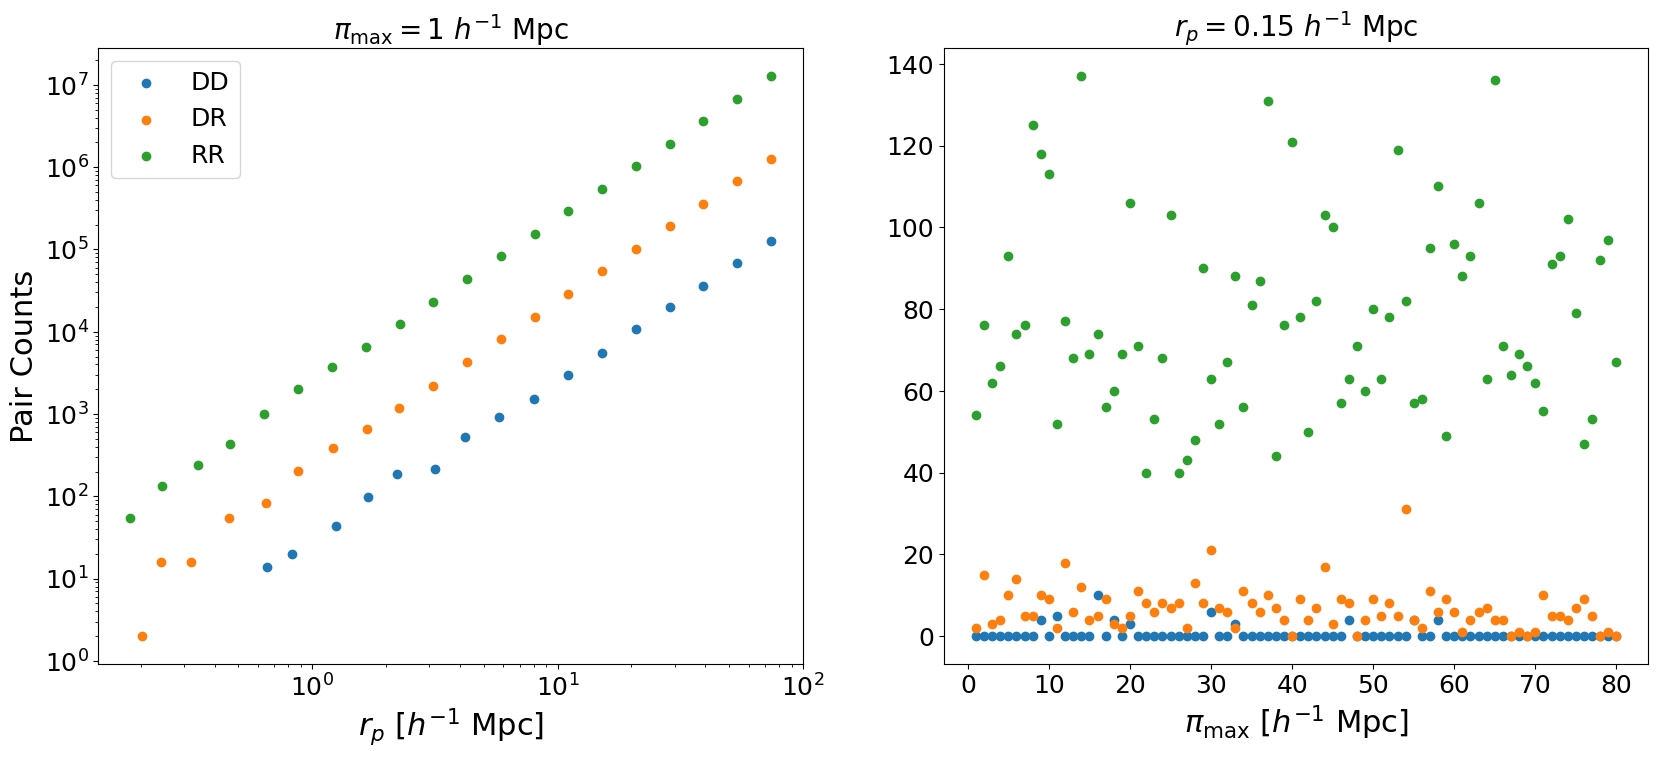

In [67]:
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2)

ax = fig.add_subplot(gs[0])
plot_counts(DD_counts, 'pimax', 1, ax, 'rpavg', 'DD')
plot_counts(DR_counts, 'pimax', 1, ax, 'rpavg', 'DR')
plot_counts(RR_counts, 'pimax', 1, ax, 'rpavg', 'RR')
ax.set_title('$\pi_\mathrm{max}=1$ $h^{-1}$ Mpc')
ax.set_xlabel(r'$r_{p}$ $[h^{-1}$ Mpc]') # projected
ax.set_ylabel("Pair Counts")
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend()

ax = fig.add_subplot(gs[1])
plot_counts(DD_counts, 'rmin', rbins[0], ax, 'pimax', 'DD')
plot_counts(DR_counts, 'rmin', rbins[0], ax, 'pimax', 'DR')
plot_counts(RR_counts, 'rmin', rbins[0], ax, 'pimax', 'RR')
ax.set_title(r'$r_{{p}}={:.2f}$ $h^{{-1}}$ Mpc'.format(rbins[0]))
ax.set_xlabel('$\pi_{\mathrm{max}}$ $[h^{-1}$ Mpc]') # line of sight
# ax.set_yscale('log')
plt.show()

### Now convert the 2-D Pair counts into a $w_p(r_p)$


In [68]:
# All the pair counts are done, get the angular correlation function
wp = convert_rp_pi_counts_to_wp(N_gcatlo_mask, N_gcatlo_mask, int(N_randlo_mask/d), int(N_randlo_mask/d),
                                DD_counts, DR_counts, DR_counts, RR_counts, nbins, pimax)

In [69]:
# calculate the x axis
rpavg = [np.sum((DD_counts['rpavg']*DD_counts['npairs'])[DD_counts['rmin']==i])/np.sum(DD_counts['npairs'][DD_counts['rmin']==i]) 
         for i in rbins[:-1]]

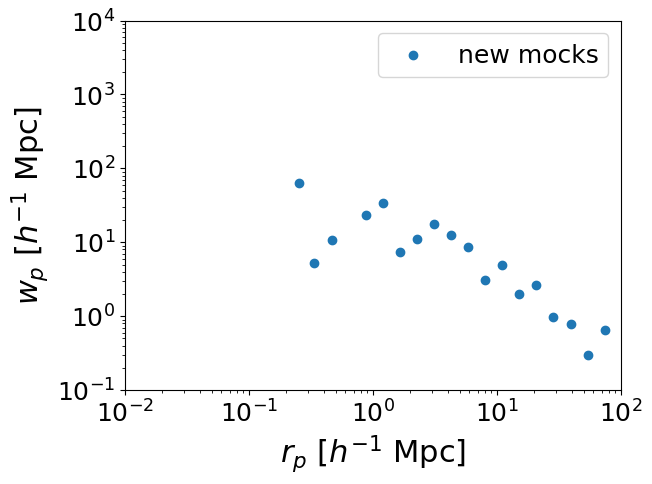

In [70]:
plt.scatter(rpavg, wp, label = 'new mocks')
plt.xlabel(r'$r_{p}$ $[h^{-1}$ Mpc]') # projected
plt.ylabel("$w_p$ $[h^{-1}$ Mpc]")
plt.xscale('log')
plt.yscale('log')
plt.xlim(1e-2,1e2)
plt.ylim(1e-1,1e4)
plt.legend()
plt.show()

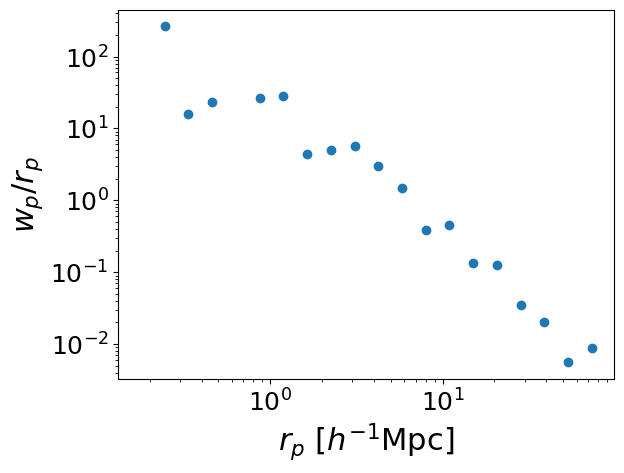

In [71]:
plt.scatter(quaia.recenter(rbins), wp/quaia.recenter(rbins), label = 'Mpc')
plt.xlabel(r'$r_{p}$ $[h^{-1}$Mpc]') # projected
plt.ylabel(r"$w_p/r_p$")
plt.xscale('log')
plt.yscale('log')
plt.show()

### Check impact of $\pi_\mathrm{max}$

In [72]:
pimax_array = [40, 80, 120, 160, 200]

In [73]:
wp_data_pimax, rpavg_data_pimax = [], []
for pi in pimax_array:
    
    wp_data_pi, rpavg_data_pi = quaia.wp_rp(tab_datalo[mask_datalo], tab_randlo[mask_randlo], selfunc_lo, pixel_indices_datalo_mask, 
                                      pixel_indices_randlo_mask, N_datalo_mask, N_randlo_mask, RR_counts = None, rmin = rmin, rmax = rmax, pimax = pi, 
                                            mask = mask, nthreads = nthreads)
    wp_data_pimax.append(wp_data_pi)
    rpavg_data_pimax.append(rpavg_data_pi)

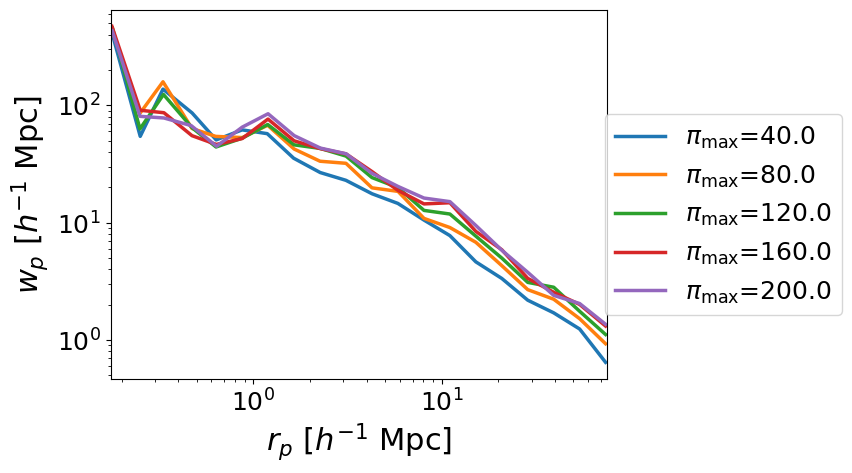

In [74]:
for i in range(len(wp_data_pimax)):
    
    plt.plot(rpavg_data_pimax[i], wp_data_pimax[i], label = '$\pi_\mathrm{{max}}$={:.1f}'.format(pimax_array[i]), linewidth = 2.5)
    plt.xlabel(r'$r_{p}$ $[h^{-1}$ Mpc]') # projected
    plt.ylabel("$w_p$ $[h^{-1}$ Mpc]")
    plt.xlim(rmin+0.025, rmax-10)
    plt.xscale('log')
    plt.yscale('log')
    plt.legend(bbox_to_anchor=(1, 0.25, 0.5, 0.5))
    
plt.show()

### Check impact of d

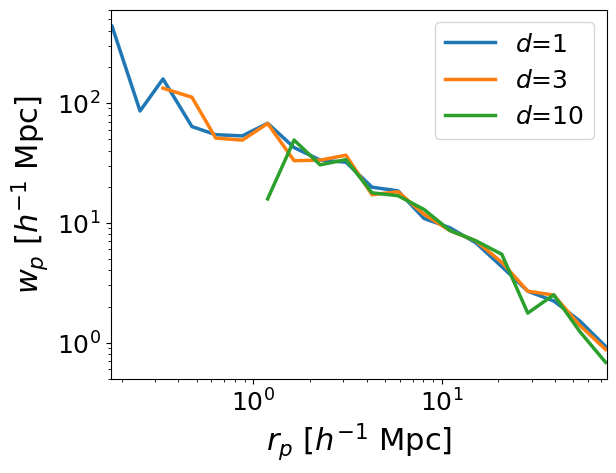

In [75]:
for d in [1, 3, 10]:
    
    wp_data_d, rpavg_data_d = quaia.wp_rp(tab_datalo[mask_datalo], tab_randlo[mask_randlo], selfunc_lo, pixel_indices_datalo_mask, 
                                          pixel_indices_randlo_mask, N_datalo_mask, N_randlo_mask, RR_counts = None, rmin = rmin, rmax = rmax, 
                                          pimax = pimax, d = d, mask = mask, nthreads = nthreads)
    plt.plot(rpavg_data_d, wp_data_d, label = '$d$={:d}'.format(d), linewidth = 2.5)
    plt.xlabel(r'$r_{p}$ $[h^{-1}$ Mpc]') # projected
    plt.ylabel("$w_p$ $[h^{-1}$ Mpc]")
    plt.xlim(rmin+0.025, rmax-10)
    plt.xscale('log')
    plt.yscale('log')
    plt.legend()
    
plt.show()

### See the limit of $w_p(r_p, \pi_\mathrm{max} \rightarrow \infty)$

In [76]:
wp_data_lim, rpavg_data_lim = quaia.wp_rp(tab_datalo[mask_datalo], tab_randlo[mask_randlo], selfunc_lo, pixel_indices_datalo_mask, 
                                          pixel_indices_randlo_mask, N_datalo_mask, N_randlo_mask, RR_counts = None, rmin = rmin, rmax = rmax, 
                                          pimax = 5000, d = 10, mask = mask, nthreads = nthreads)

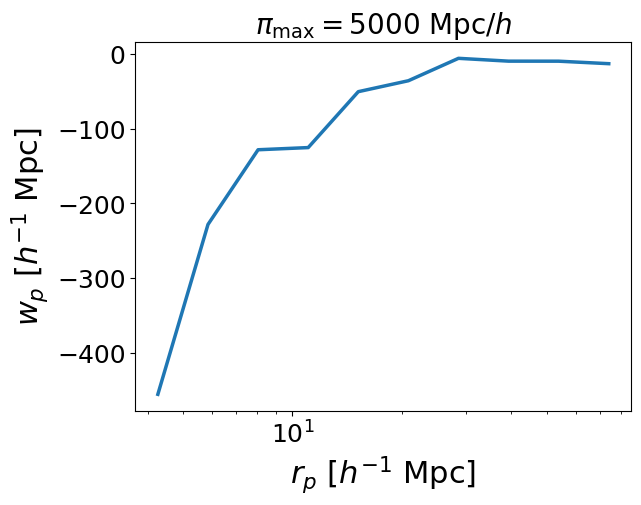

In [77]:
plt.plot(rpavg_data_lim, wp_data_lim, linewidth = 2.5)
plt.xlabel(r'$r_{p}$ $[h^{-1}$ Mpc]') # projected
plt.ylabel("$w_p$ $[h^{-1}$ Mpc]")
plt.xscale('log')
plt.title('$\pi_\mathrm{max}=5000$ Mpc$/h$')
    
plt.show()

### Compare to data

In [78]:
wp_mock, rpavg_mock = quaia.wp_rp(tab_gcatlo[mask_gcatlo], tab_randlo[mask_randlo], selfunc_lo, pixel_indices_gcatlo_mask, pixel_indices_randlo_mask, 
                                  N_gcatlo_mask, N_randlo_mask, RR_counts, rmin = rmin, rmax = rmax, pimax = pimax, mask = mask, nthreads = nthreads)

/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/notebooks/quaia.py:261: FutureWarning: elementwise == comparison failed and returning scalar instead; this will raise an error or perform elementwise comparison in the future.
  weights2 = 1/selfunc_lo[pixel_indices_randlo][::d], weight_type='pair_product',


In [79]:
wp_data, rpavg_data = quaia.wp_rp(tab_datalo[mask_datalo], tab_randlo[mask_randlo], selfunc_lo, pixel_indices_datalo_mask, pixel_indices_randlo_mask, 
                                  N_datalo_mask, N_randlo_mask, RR_counts, rmin = rmin, rmax = rmax, pimax = pimax, mask = mask, nthreads = nthreads)

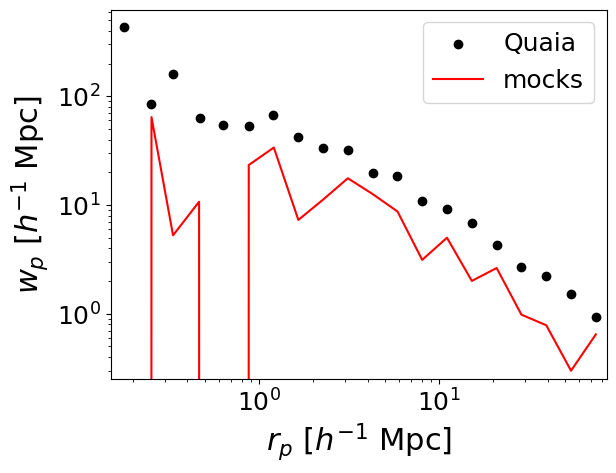

In [80]:
plt.scatter(rpavg_data, wp_data, label = 'Quaia', color = 'black')
plt.plot(rpavg_mock, wp_mock, label = 'mocks', color = 'red')
plt.xlabel(r'$r_{p}$ $[h^{-1}$ Mpc]') # projected
plt.ylabel("$w_p$ $[h^{-1}$ Mpc]")
plt.xscale('log')
plt.yscale('log')
plt.xlim(rmin, rmax)
plt.ylim(2.5e-1,)
plt.legend()
plt.show()

### Average the mocks

In [81]:
wp_mocks, rpavg_mocks = [], []
for i in range(1,31):
    fn_gcatlo_i = '../Quaia_mock_catalogs-20250211T213139Z-001/Quaia_mock_catalogs/G20/mock_catalog_quaia_G20_mock{}.fits'.format(str(i))
    tab_gcatlo_i, pixel_indices_gcatlo_mask_i, N_gcatlo_mask_i, mask_gcatlo_i = quaia.read(fn_gcatlo_i, G_lo, 
                                                                                           fn_sello, mask = mask)
    wp_mock_i, rpavg_mock_i = quaia.wp_rp(tab_gcatlo_i[mask_gcatlo_i], tab_randlo[mask_randlo], selfunc_lo, pixel_indices_gcatlo_mask_i, 
                                      pixel_indices_randlo_mask, N_gcatlo_mask_i, N_randlo_mask, RR_counts, rmin = rmin, rmax = rmax, pimax = pimax, 
                                          mask = mask, nthreads = nthreads)
    wp_mocks.append(wp_mock_i)
    rpavg_mocks.append(rpavg_mock_i)

Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra

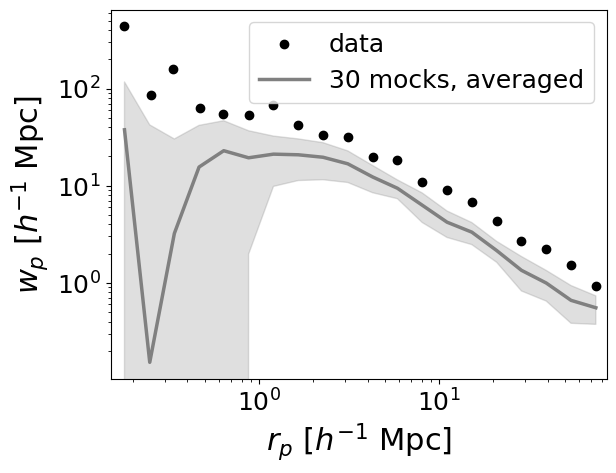

In [82]:
plt.scatter(rpavg_data, wp_data, label = 'data', color = 'black')

wp_mocks_mean = np.mean(wp_mocks, axis = 0)
rpavg_mocks_mean = np.mean(rpavg_mocks, axis = 0)
yerr = np.std(wp_mocks, axis = 0)
plt.plot(rpavg_mocks_mean, wp_mocks_mean, label = '30 mocks, averaged', color = 'gray', linewidth = 2.5)
plt.fill_between(rpavg_mocks_mean, y1 = wp_mocks_mean - yerr, y2 = wp_mocks_mean + yerr, color = 'gray', alpha = 0.25)
plt.xlabel(r'$r_{p}$ $[h^{-1}$ Mpc]') # projected
plt.ylabel("$w_p$ $[h^{-1}$ Mpc]")
plt.xscale('log')
plt.xlim(rmin, rmax)
plt.yscale('log')
plt.legend()
plt.show()

### Compare to https://arxiv.org/abs/2506.05612
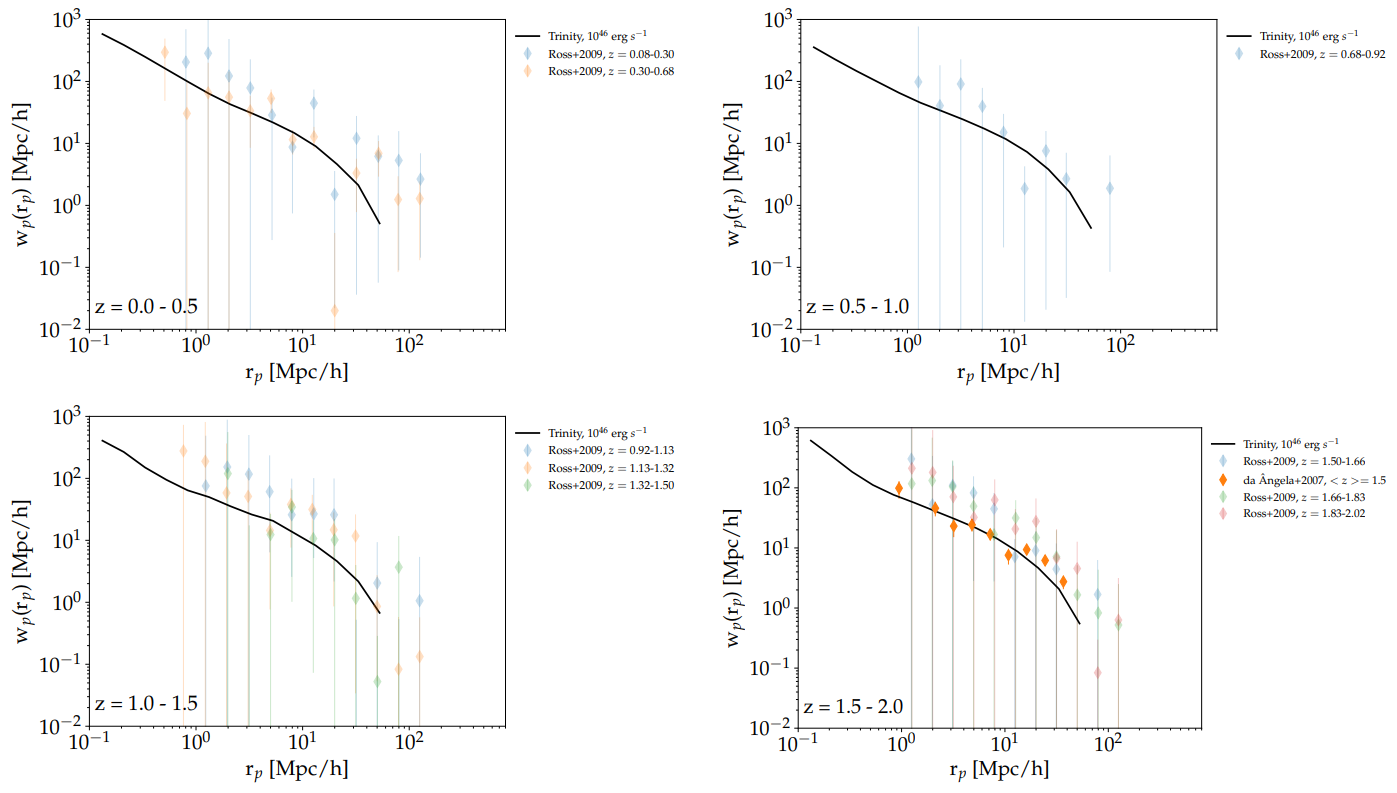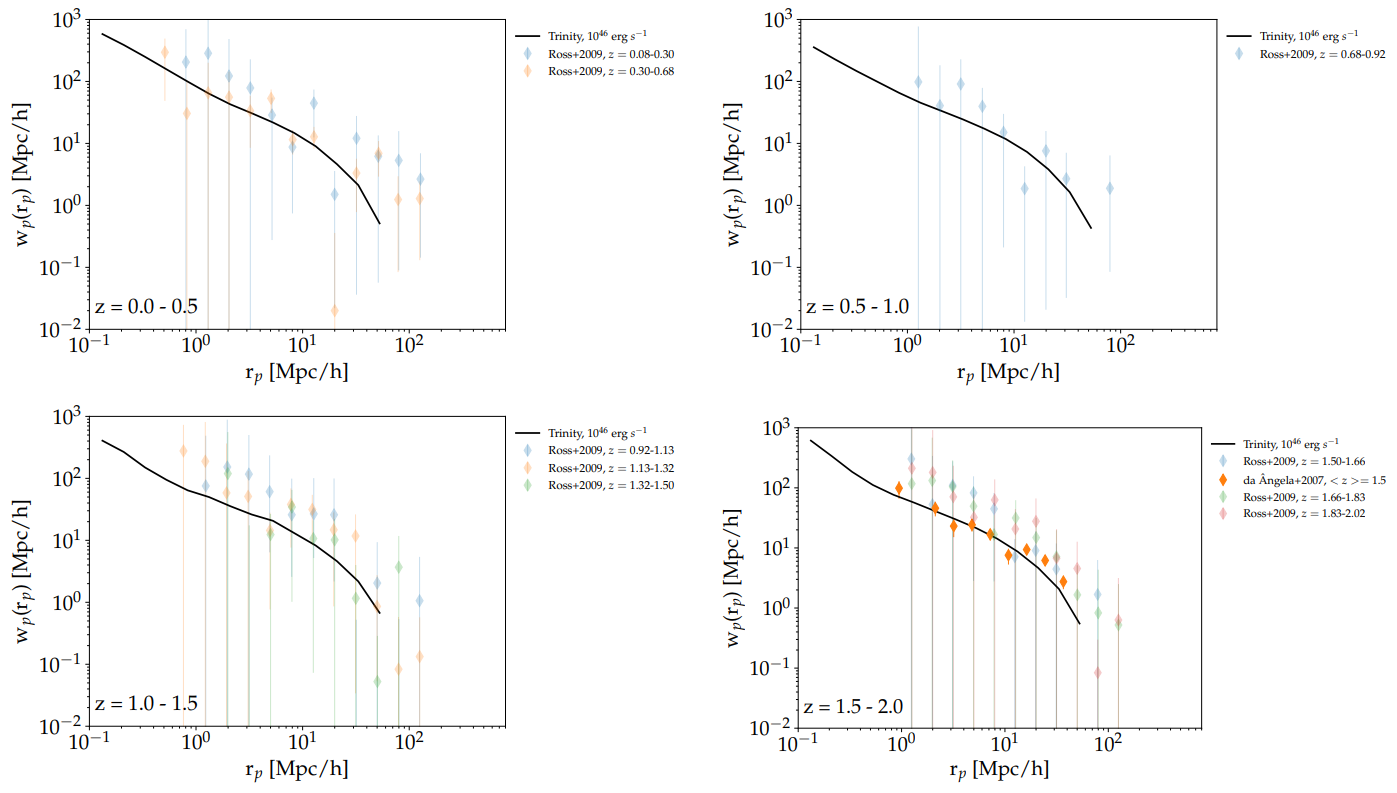

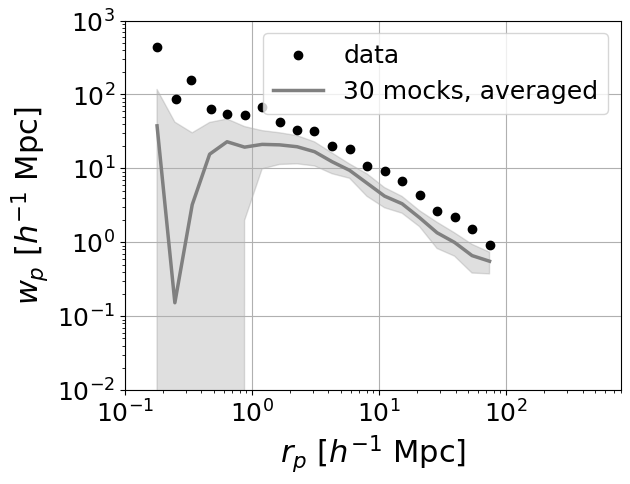

In [83]:
wp_mocks_mean = np.mean(wp_mocks, axis = 0)
rpavg_mocks_mean = np.mean(rpavg_mocks, axis = 0)
yerr = np.std(wp_mocks, axis = 0)

plt.scatter(rpavg_data, wp_data, label = 'data', color = 'black', zorder = 3)
plt.plot(rpavg_mocks_mean, wp_mocks_mean, label = '30 mocks, averaged', color = 'gray', linewidth = 2.5)
plt.fill_between(rpavg_mocks_mean, y1 = wp_mocks_mean - yerr, y2 = wp_mocks_mean + yerr, color = 'gray', alpha = 0.25)

plt.xlabel(r'$r_{p}$ $[h^{-1}$ Mpc]') # projected
plt.ylabel("$w_p$ $[h^{-1}$ Mpc]")
plt.xscale('log')
plt.xlim(1e-1, 8e2)
plt.ylim(1e-2, 1e3)
plt.yscale('log')
plt.legend()
plt.grid()
plt.show()

## Check impact of masking

Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/notebooks/quaia.py:93: RuntimeWarning: invalid value encountered in true_divide
  cbar_ticks=[5, 10, 20])
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/notebooks/quaia.py:93: RuntimeWarning: invalid value encountered in true_divide
  cbar_ticks=[5, 10, 20])
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/notebooks/quaia.py:93: RuntimeWarning: invalid value encountered in true_divide
  cbar_ticks=[5, 10, 20])
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/notebooks/quaia.py:93: RuntimeWarning: invalid value encountered in true_divide
  cbar_ticks=[5, 10, 20])
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


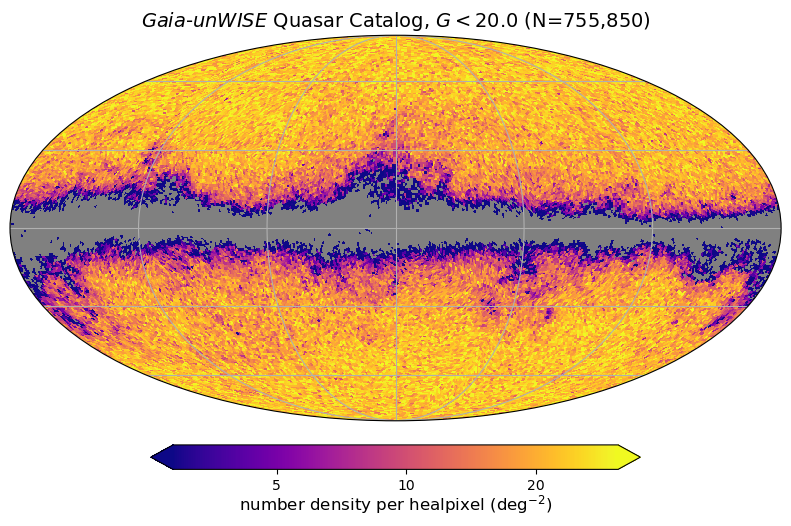

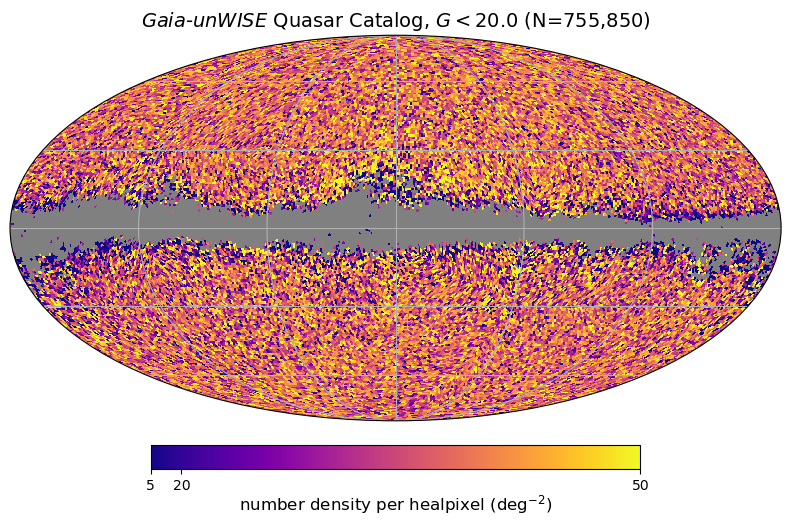

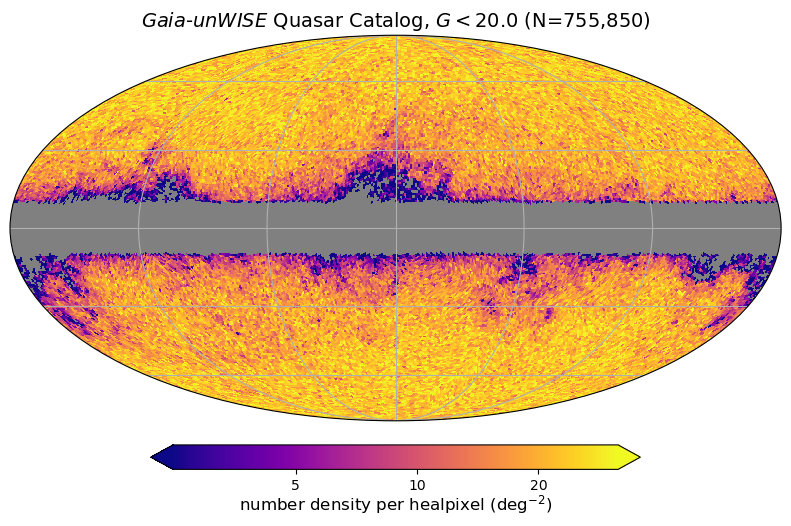

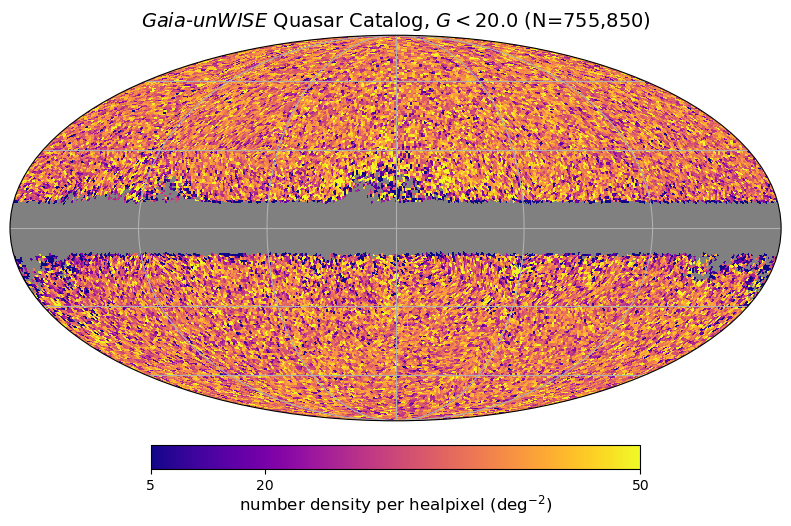

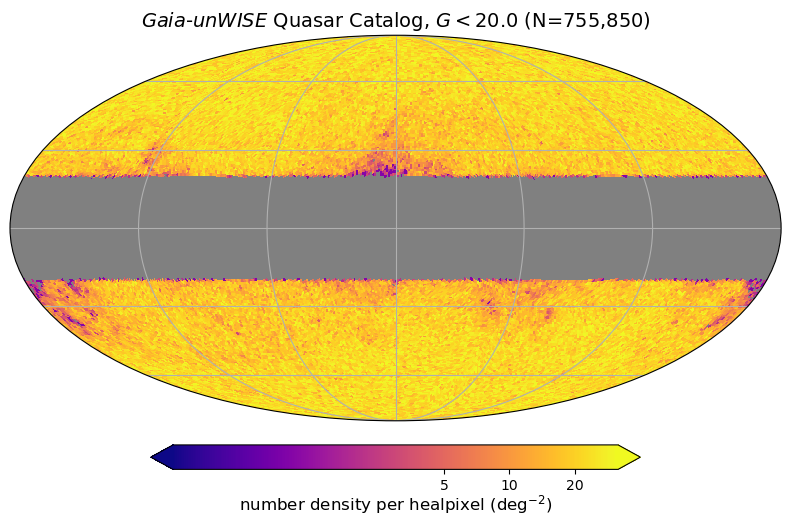

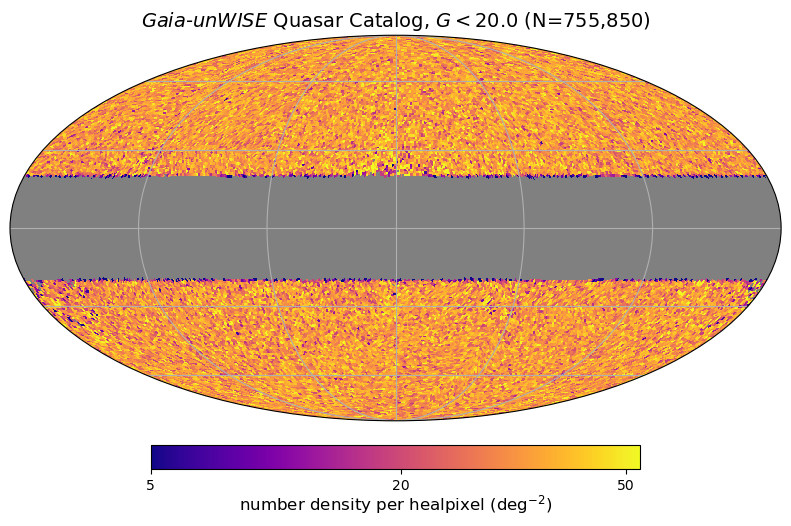

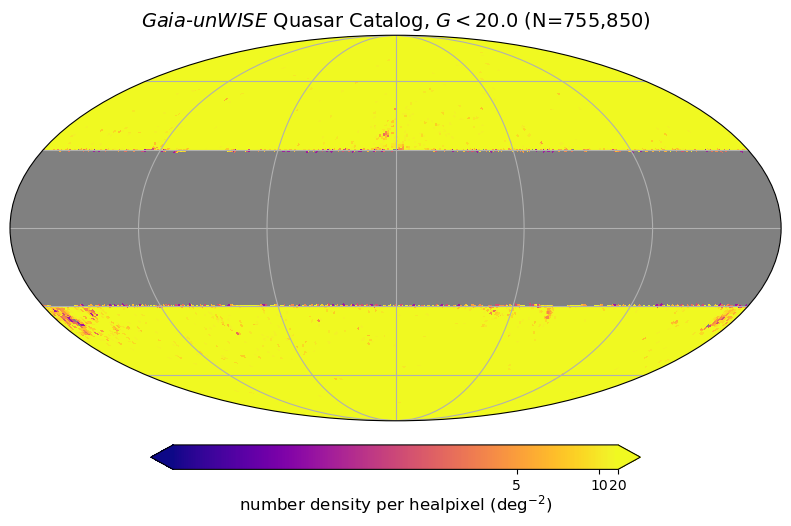

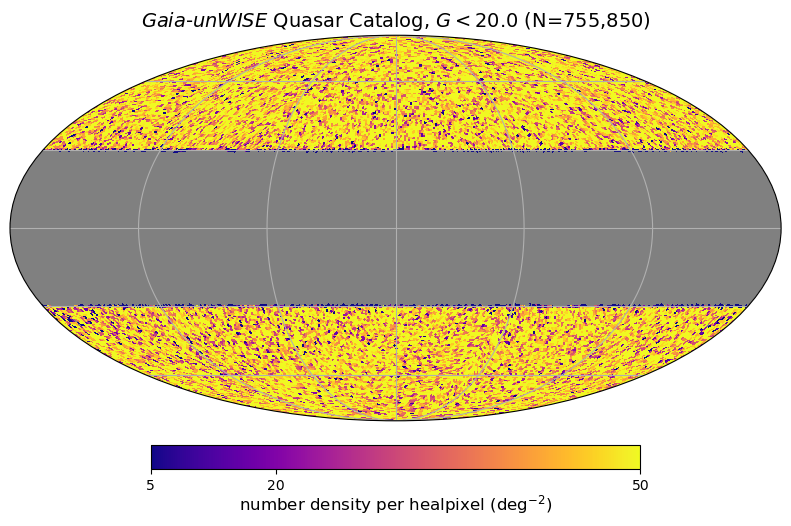

In [84]:
wp_data_b_array, rpavg_data_b_array = [], []
b_array = [0, 10, 20, 30]
fac_stdev_array = [1.5, 1.5, 1.45, 0.5] #1.45, 0.5
for i in range(len(b_array)):
    
    _, pixel_indices_datalo_b, N_datalo_b, mask_datalo_b = quaia.read(f'../data/quaia_G20.0.fits', G_lo, fn_sello, 
                                                                mask = b_array[i], plot = True, fac_stdev = fac_stdev_array[i])

    mask_randlo_b = np.abs(c_randlo.galactic.b.value)>=b_array[i] # use galactic coordinates from data 
    N_randlo_b = len(tab_randlo['ra'][mask_randlo_b])
    quaia.z_dist(tab_datalo, tab_randlo, mask_datalo_b, mask_randlo_b, N_datalo_b, N_randlo_b, mask = b_array[i])
    
    pixel_indices_randlo_b = hp.ang2pix(NSIDE, tab_randlo['ra'][mask_randlo_b], tab_randlo['dec'][mask_randlo_b], lonlat=True)
    wp_data_b, rpavg_data_b = quaia.wp_rp(tab_datalo[mask_datalo_b], tab_randlo[mask_randlo_b], selfunc_lo, pixel_indices_datalo_b, 
                                          pixel_indices_randlo_b, N_datalo_b, N_randlo_b, None, rmin = rmin, rmax = rmax, pimax = pimax, 
                                          mask = b_array[i], nthreads = nthreads)
    
    wp_data_b_array.append(wp_data_b)
    rpavg_data_b_array.append(rpavg_data_b)

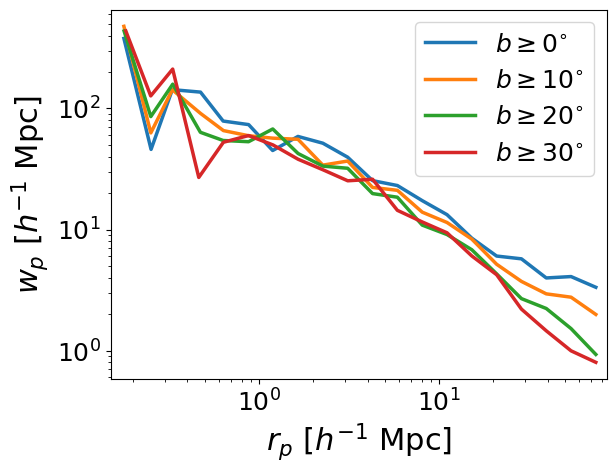

In [85]:
for i in range(len(b_array)):
    plt.plot(rpavg_data_b_array[i], wp_data_b_array[i], label = '$b\geq{:d}^{{\circ}}$'.format(b_array[i]),linewidth = 2.5)
plt.xlabel(r'$r_{p}$ $[h^{-1}$ Mpc]') # projected
plt.ylabel("$w_p$ $[h^{-1}$ Mpc]")
plt.xscale('log')
plt.xlim(rmin, rmax)
plt.yscale('log')
plt.legend()
plt.show()

# Questions
- why are npairs higher for lower pimax?
- negative wp? due to DR? bad? --> no sometimes clustering is negative (voids)
- why do they use hubble distance if z is not << 1?
- does wp still get rid of RSDs if we are integrating to pimax and not infinity? --> yes because the rest is noise
- why does masking not converge for higher b?